In [49]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          20-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

# Importeeer de benodigde packages.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, RocCurveDisplay,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score



data_train = pd.read_csv("data_train.csv")

In [50]:
# numerieke kolommen en categorische kolommen waarbij het referentie niveau gedropt wordt.
numcols = ['Call Failure','Subscription Length','Seconds of Use','Frequency of use','Frequency of SMS']
faccols = ['Age Group','Complaints']
droplevels = [1,0]

# columntransformer voor de datapreperatie fase.
dataprep = ColumnTransformer([
    ('numeriek', StandardScaler(), numcols),
    ('categorisch', OneHotEncoder(drop = droplevels, sparse_output=False), faccols),
], remainder = 'drop', verbose_feature_names_out = False)

dataprep.set_output(transform='pandas')
dataprep

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [51]:
# De beslisboom wordt gefit.
X_train = data_train.drop(columns = ['Churn'])
y_train = data_train['Churn']

model = Pipeline([('preprocessing', dataprep),
                  ('model', DecisionTreeClassifier(max_depth = 3,
                                                   min_samples_leaf=1))])
# de hyperparameters zijn zo gekozen,omdat het aanbevolen wordt door de userguide van sklearn.
model.fit(X_train, y_train)
y_pred =model.predict(X_train)
print(f'accuracy model: {accuracy_score(y_pred,y_train):.2f}')



accuracy model: 0.90


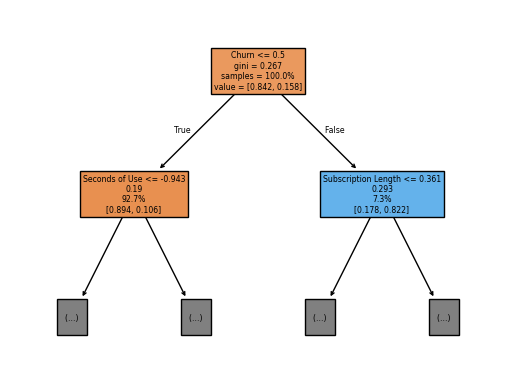

In [52]:
# In deze cel wordt een plot gemaakt van de boom.
# De diepte van de plot is 1 zodat de waarden duidelijk zichtbaar.

plot_tree(model.named_steps['model'],
            max_depth = 1,
            feature_names = data_train.columns,
            filled = True,
            proportion=True,
            label = 'root')
plt.show()


In [53]:
# De waardes van alpha worden gehaald uit de volledige boom.

alphas = DecisionTreeClassifier(max_depth = 3,min_samples_leaf = 1).fit(X_train, y_train).cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(alphas['ccp_alphas'])

In [54]:
# Hieronder wordt een gridsearch uitgevoerd om de beste waarde van alpha te bepalen.
# Dit doen wij aan de hand van de roc_auc score.

gridsearch = GridSearchCV(
    model,
    param_grid = {'model__ccp_alpha' : alphas},
    scoring = 'accuracy',
    n_jobs=-2).fit(X_train, y_train)


best_alpha = gridsearch.best_params_['model__ccp_alpha']
best_score = gridsearch.best_score_

print(f'Best gevonden alpha: {best_alpha:.4e}, accuracy = {best_score:.2f}')

Best gevonden alpha: 0.0000e+00, accuracy = 0.90


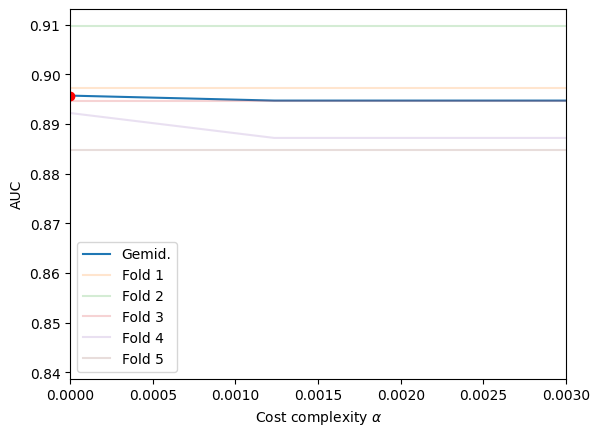

In [55]:
# In deze cel wordt een plot gemaakt waarbij de alpha uitgezet wordt tegen de auc-score.

sns.lineplot(gridsearch.cv_results_, x = 'param_model__ccp_alpha', y = 'mean_test_score', label = 'Gemid.')
for i in range(5):
    sns.lineplot(gridsearch.cv_results_, 
                 x = 'param_model__ccp_alpha', 
                 y = f'split{i}_test_score', 
                 alpha = 0.2, 
                 label = f'Fold {i+1}')
plt.plot(best_alpha, best_score, 'ro')
plt.xlim(0, 0.003)
plt.xlabel('Cost complexity $\\alpha$')
plt.ylabel('AUC')
plt.show()

c:\Users\Eigenaar\python Toegepaste Wiskunde\envs\BP3.4\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


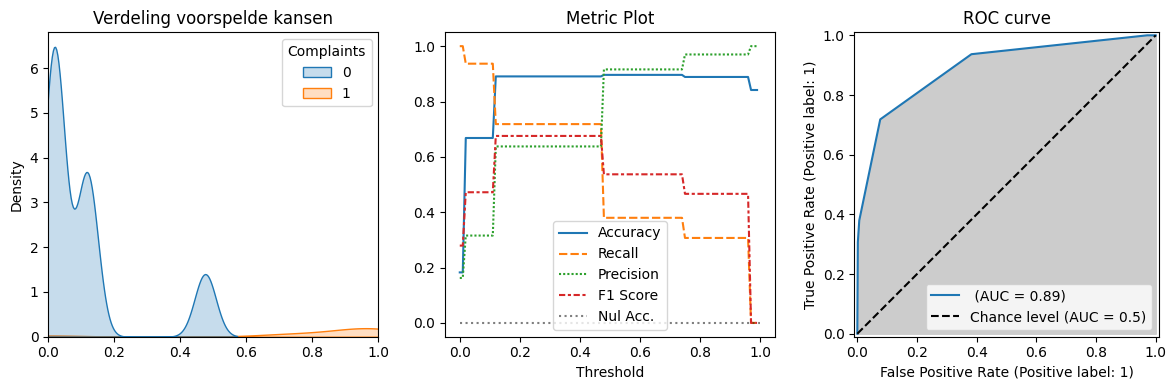

accuracy model: 0.90


In [56]:
# In deze  cel worden 3  plots gemaakt de verdeling voorspelde kansen, een metric plot en een roc curve.
y_pred = gridsearch.predict_proba(X_train)

# Functie die een classificatie report omzet in rijen van een dataframe.
def make_row(cr):
    return {
        'Accuracy':  cr['accuracy'],
        'Recall':    cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 Score':  cr['1']['f1-score']
    }

thresholds = np.arange(0, 1, 0.01)
plot_data = pd.DataFrame([
    make_row(classification_report(
        y_train, 
        y_pred[:,1] > t, 
        zero_division=True, 
        output_dict=True)) for t in thresholds])
plot_data.index = thresholds

plt.figure(figsize=(12,4), layout='tight')

# Plot 1: Verdeling van de voorspelde kansen.
plt.subplot(1,3,1)
sns.kdeplot(data_train, x = y_pred[:,1], hue = 'Complaints',fill = True)
plt.xlim(0,1)
plt.title('Verdeling voorspelde kansen')

# Plot 2: Een metric plot.
nul_acc = 0
plt.subplot(1,3,2)
sns.lineplot(plot_data)
plt.plot([0,1], [nul_acc, nul_acc], 'k:', alpha = 0.5, label = 'Nul Acc.')
plt.xlabel('Threshold')
plt.legend()
plt.title('Metric Plot')


# Plot 3: Een ROC curve.
ax = plt.subplot(1,3,3)
roc = RocCurveDisplay.from_predictions(
    y_train, 
    y_pred=y_pred[:,1], 
    name = '', 
    plot_chance_level = True,
    ax=ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()
print(f'accuracy model: {accuracy_score(gridsearch.predict(X_train),y_train):.2f}')



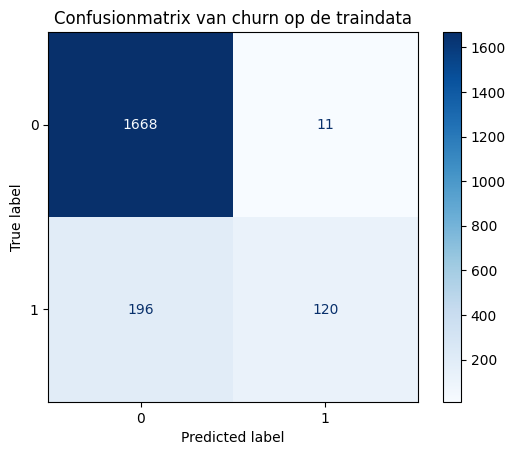

recall score van het model:0.92
precision score van het model:0.38
F1 score van het model:0.54


In [57]:
# Confusionmatrix van de voorspelling.

y_pred = gridsearch.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train,y_pred, cmap = 'Blues')
plt.title('Confusionmatrix van churn op de traindata')
plt.show()

print(f'recall score van het model:{recall_score(y_pred,y_train):.2f}')
print(f'precision score van het model:{precision_score(y_pred,y_train):.2f}')
print(f'F1 score van het model:{f1_score(y_pred,y_train):.2f}')